In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("EMG gesture decoding notebook is ready.")

EMG gesture decoding notebook is ready.


# EMG Data Exploration

**Objective:** Load one public sEMG recording, inspect its structure, and visualize the eight raw EMG channels.

**Dataset:** UCI EMG Data for Gestures  
**Note:** This notebook is for educational and research demonstration purposes only.

In [2]:
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

print(f"Loaded file: {filename}")

Saving 1_raw_data_10-38_11.04.16.txt to 1_raw_data_10-38_11.04.16.txt
Loaded file: 1_raw_data_10-38_11.04.16.txt


In [3]:
column_names = [
    "time",
    "channel_1",
    "channel_2",
    "channel_3",
    "channel_4",
    "channel_5",
    "channel_6",
    "channel_7",
    "channel_8",
    "gesture"
]

df = pd.read_csv(
    filename,
    sep="\t",
    header=None,
    names=column_names
)

print("Data shape:", df.shape)
display(df.head())
print("\nGesture labels found:", sorted(df["gesture"].unique()))

Data shape: (51079, 10)


,time,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,gesture
0,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class
1,1,-1e-05,-4e-05,-2e-05,1e-05,0,-1e-05,0,-3e-05,0
2,5,-1e-05,-4e-05,-2e-05,1e-05,0,-1e-05,0,-3e-05,0
3,6,-1e-05,-4e-05,-2e-05,1e-05,0,-1e-05,0,-3e-05,0
4,7,-1e-05,-4e-05,-2e-05,1e-05,0,-1e-05,0,-3e-05,0



Gesture labels found: ['0', '1', '2', '3', '4', '5', '6', 'class']


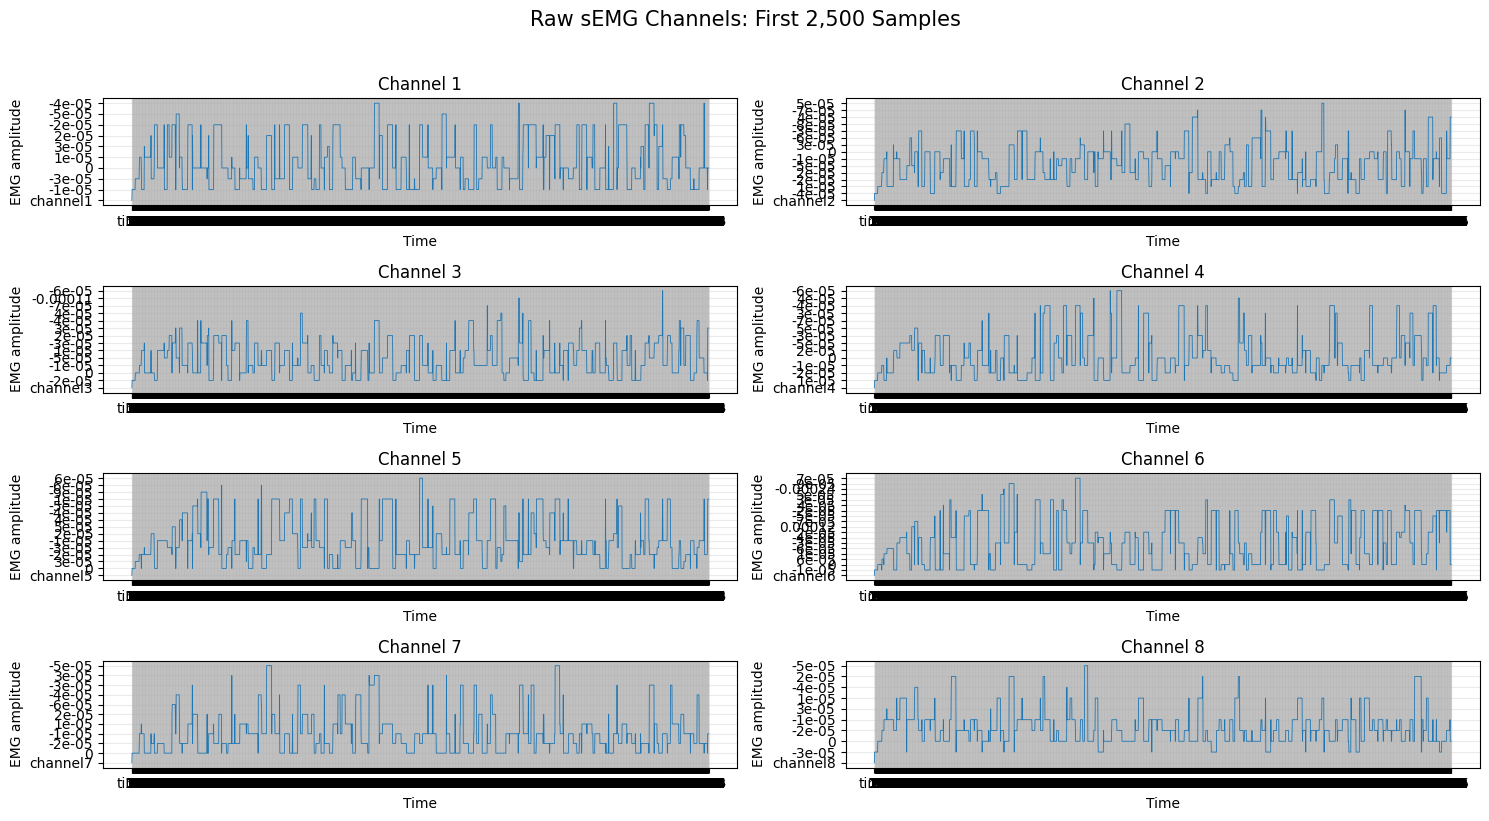

In [5]:
channels = [f"channel_{i}" for i in range(1, 9)]

segment = df.iloc[:2500]

plt.figure(figsize=(15, 8))

for i, channel in enumerate(channels, start=1):
    plt.subplot(4, 2, i)
    plt.plot(segment["time"], segment[channel], linewidth=0.6)
    plt.title(channel.replace("_", " ").title())
    plt.xlabel("Time")
    plt.ylabel("EMG amplitude")
    plt.grid(alpha=0.25)

plt.suptitle("Raw sEMG Channels: First 2,500 Samples", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
df = pd.read_csv(filename, sep="\t")

df.columns = [
    "time",
    "channel_1",
    "channel_2",
    "channel_3",
    "channel_4",
    "channel_5",
    "channel_6",
    "channel_7",
    "channel_8",
    "gesture"
]

df["gesture"] = pd.to_numeric(df["gesture"])

print("Cleaned data shape:", df.shape)
print("Gesture labels found:", sorted(df["gesture"].unique()))
display(df.head())

Cleaned data shape: (51078, 10)
Gesture labels found: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


,time,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,gesture
0,1,-0.00001,-0.00004,-0.00002,0.00001,0.0,-0.00001,0.0,-0.00003,0
1,5,-0.00001,-0.00004,-0.00002,0.00001,0.0,-0.00001,0.0,-0.00003,0
2,6,-0.00001,-0.00004,-0.00002,0.00001,0.0,-0.00001,0.0,-0.00003,0
3,7,-0.00001,-0.00004,-0.00002,0.00001,0.0,-0.00001,0.0,-0.00003,0
4,8,-0.00001,-0.00004,-0.00002,0.00001,0.0,-0.00001,0.0,-0.00003,0


Samples per gesture class:
gesture
0    30675
1     3393
2     3330
3     3260
4     3281
5     3944
6     3195
Name: count, dtype: int64


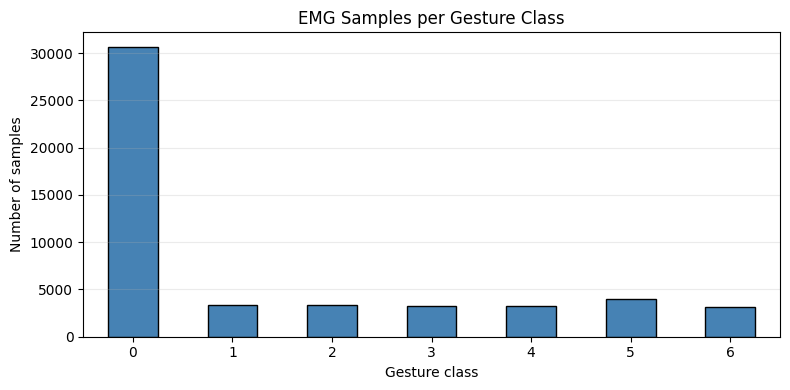

In [7]:
gesture_counts = df["gesture"].value_counts().sort_index()

print("Samples per gesture class:")
print(gesture_counts)

plt.figure(figsize=(8, 4))
gesture_counts.plot(kind="bar", color="steelblue", edgecolor="black")

plt.title("EMG Samples per Gesture Class")
plt.xlabel("Gesture class")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [8]:
target_gesture = 1

gesture_1 = df[df["gesture"] == target_gesture].copy()

print(f"Samples with gesture {target_gesture}: {len(gesture_1)}")
display(gesture_1.head())

Samples with gesture 1: 3393


,time,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,gesture
901,968,-0.00002,0.00003,0.00001,0.00003,0.00000,-0.00003,-0.00004,-0.00001,1
902,969,0.00001,0.00003,0.00001,0.00000,-0.00001,-0.00002,-0.00001,0.00000,1
903,970,0.00001,0.00003,0.00001,0.00000,-0.00001,-0.00002,-0.00001,0.00000,1
904,971,0.00001,0.00003,0.00001,0.00000,-0.00001,-0.00002,-0.00001,0.00000,1
905,972,0.00001,0.00003,0.00001,0.00000,-0.00001,-0.00002,-0.00001,0.00000,1


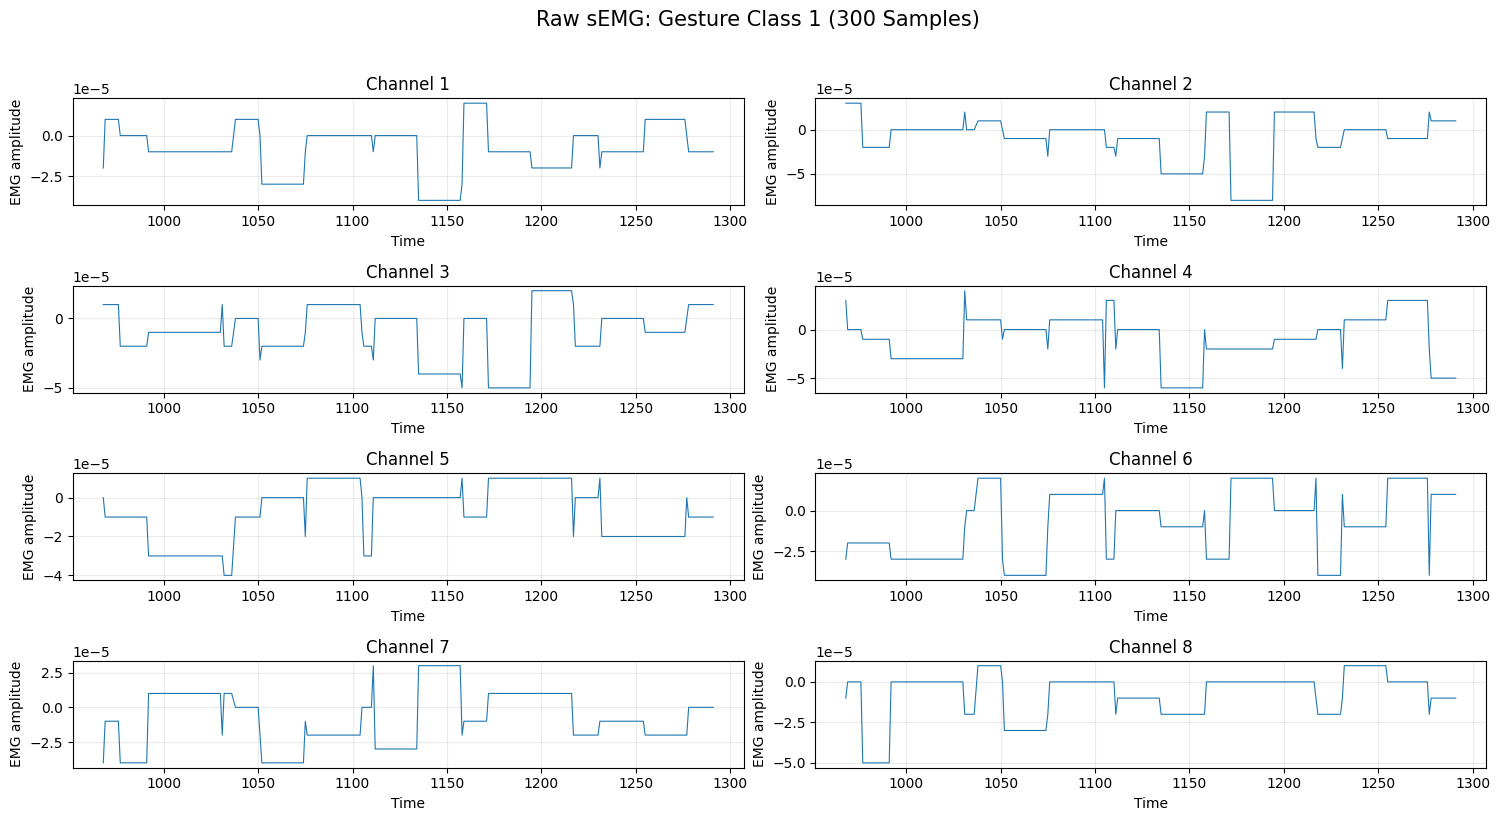

In [9]:
channels = [f"channel_{i}" for i in range(1, 9)]

segment_length = 300
segment = gesture_1.iloc[:segment_length]

plt.figure(figsize=(15, 8))

for i, channel in enumerate(channels, start=1):
    plt.subplot(4, 2, i)
    plt.plot(segment["time"], segment[channel], linewidth=0.8)
    plt.title(channel.replace("_", " ").title())
    plt.xlabel("Time")
    plt.ylabel("EMG amplitude")
    plt.grid(alpha=0.25)

plt.suptitle(
    f"Raw sEMG: Gesture Class {target_gesture} ({segment_length} Samples)",
    fontsize=15,
    y=1.02
)
plt.tight_layout()
plt.show()

In [10]:
target_gesture = 1

is_target = df["gesture"].eq(target_gesture)

block_id = is_target.ne(is_target.shift()).cumsum()

gesture_blocks = (
    df[is_target]
    .groupby(block_id[is_target])
    .agg(
        start_index=("time", "idxmin"),
        end_index=("time", "idxmax"),
        start_time=("time", "min"),
        end_time=("time", "max"),
        samples=("time", "size")
    )
    .reset_index(drop=True)
)

print(f"Continuous blocks for gesture {target_gesture}:")
display(gesture_blocks)

Continuous blocks for gesture 1:


,start_index,end_index,start_time,end_time,samples
0,901,2533,968,2661,1633
1,28133,29892,29871,31685,1760


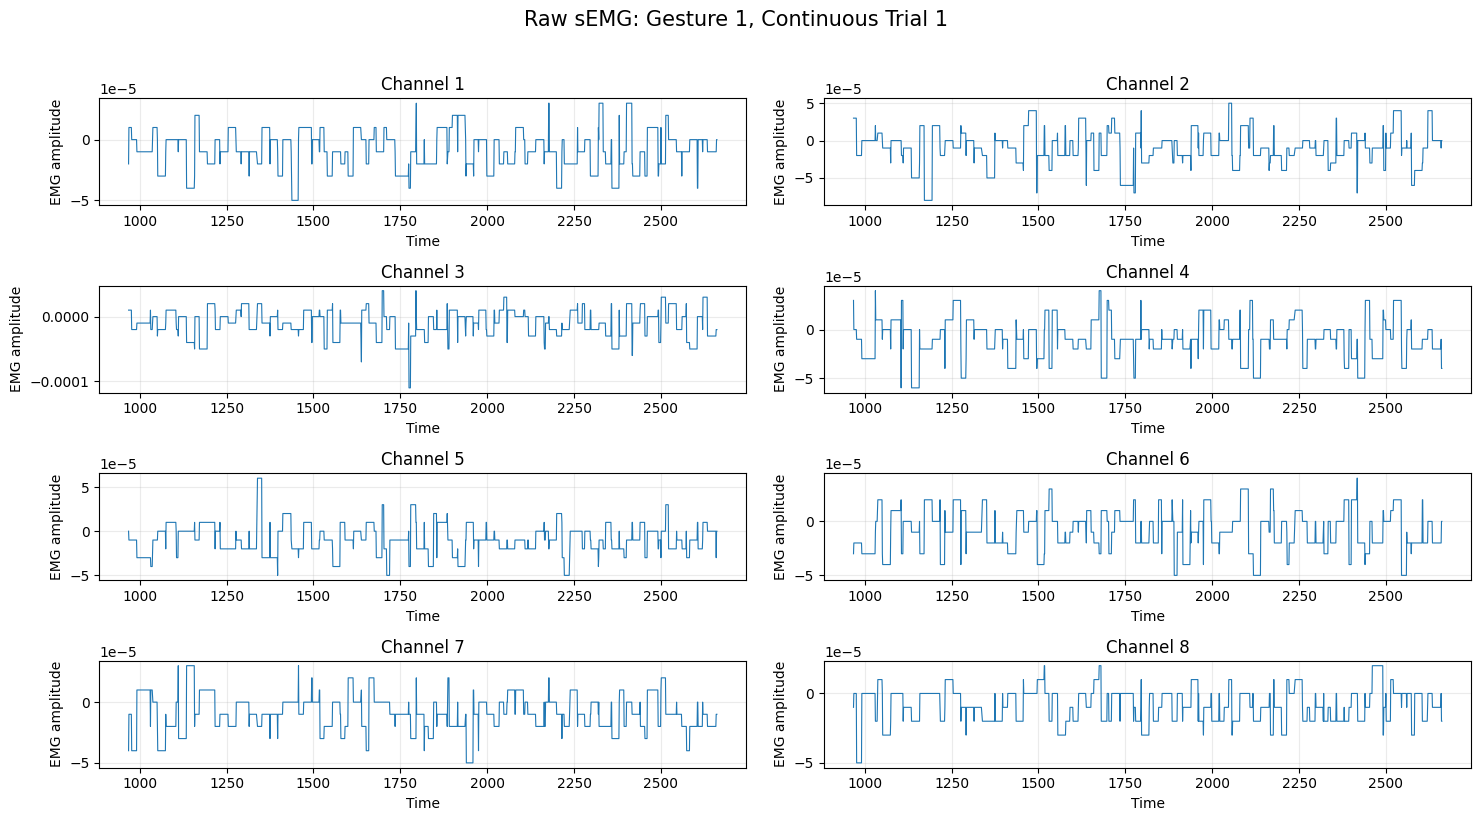

In [11]:
block_number = 0

start_time = gesture_blocks.loc[block_number, "start_time"]
end_time = gesture_blocks.loc[block_number, "end_time"]

trial = df[
    (df["gesture"] == target_gesture)
    & (df["time"] >= start_time)
    & (df["time"] <= end_time)
].copy()

channels = [f"channel_{i}" for i in range(1, 9)]

plt.figure(figsize=(15, 8))

for i, channel in enumerate(channels, start=1):
    plt.subplot(4, 2, i)
    plt.plot(trial["time"], trial[channel], linewidth=0.8)
    plt.title(channel.replace("_", " ").title())
    plt.xlabel("Time")
    plt.ylabel("EMG amplitude")
    plt.grid(alpha=0.25)

plt.suptitle(
    f"Raw sEMG: Gesture {target_gesture}, Continuous Trial {block_number + 1}",
    fontsize=15,
    y=1.02
)
plt.tight_layout()
plt.show()